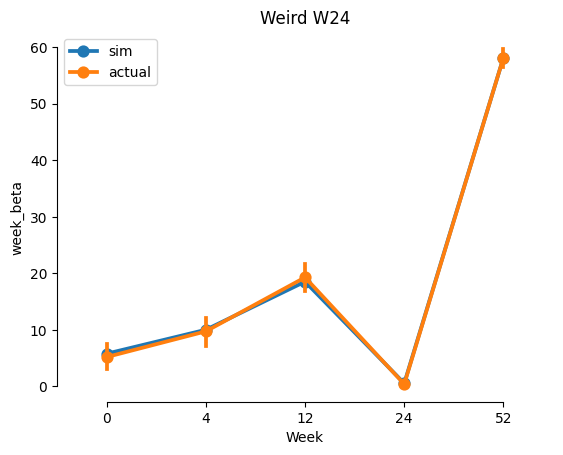

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from simulations import simulations as sim

df = sim.y_sim()
y_df = sim.y_kill(df, size = 50)

# screw up W24
y_df.loc[y_df.Week == 24, 'mean'] = np.random.rand(len(y_df[(y_df.Week == 24)]['mean']))

result24 = sim.lme_results(y_df)

sns.pointplot(data = result24, x = 'Week', y = 'week_beta', label = 'sim')
sns.pointplot(data = y_df, x = 'Week', y = 'y', label = 'actual')

plt.legend()
sns.despine(trim = True)
plt.title("Weird W24")
plt.show()

In [58]:
model = smf.mixedlm('y~0+Week', data = y_df, groups = 'subj_id').fit(maxiter = 400)
model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
=======================================================
Model:            MixedLM Dependent Variable: y        
No. Observations: 65      Method:             REML     
No. Groups:       20      Scale:              4.0172   
Min. group size:  2       Log-Likelihood:     -150.1742
Max. group size:  5       Converged:          Yes      
Mean group size:  3.2                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Week[0]       5.792    0.892  6.493 0.000  4.043  7.540
Week[4]      10.026    0.927 10.815 0.000  8.209 11.843
Week[12]     18.532    0.931 19.914 0.000 16.708 20.356
Week[24]      0.548    0.760  0.722 0.471 -0.941  2.038
Week[52]     58.152    0.727 79.950 0.000 56.726 59.577
subj_id Var   6.564    1.532                           
=======================================================

"""

In [53]:
model = smf.mixedlm('y~Week', data = y_df, groups = 'subj_id').fit(maxiter = 400)

model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
         Mixed Linear Model Regression Results
=======================================================
Model:            MixedLM Dependent Variable: y        
No. Observations: 65      Method:             REML     
No. Groups:       20      Scale:              4.0172   
Min. group size:  2       Log-Likelihood:     -150.1742
Max. group size:  5       Converged:          Yes      
Mean group size:  3.2                                  
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     5.792    0.892  6.493 0.000  4.043  7.540
Week[T.4]     4.234    0.985  4.299 0.000  2.304  6.164
Week[T.12]   12.740    1.022 12.468 0.000 10.738 14.743
Week[T.24]   -5.243    0.839 -6.251 0.000 -6.888 -3.599
Week[T.52]   52.360    0.818 64.042 0.000 50.757 53.962
subj_id Var   6.564    1.532                           
=======================================================

"""

<ErrorbarContainer object of 3 artists>

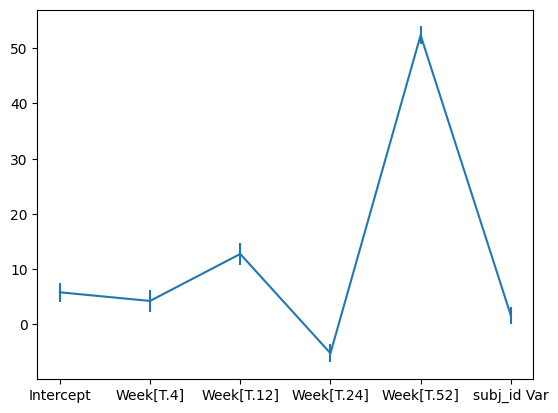

In [2]:
import statsmodels.formula.api as smf

model = smf.mixedlm('y~Week', data = y_df, groups = 'subj_id').fit(maxiter = 400)

ci = model.conf_int()
yerr_lower = model.params - ci[0]
yerr_upper = ci[1] - model.params
plt.errorbar(model.params.index, model.params, yerr=[yerr_lower, yerr_upper])

In [ ]:
import pandas as pd

def _fe_results_df(model):

    fe = model.fe_params
    ci = model.conf_int().loc[fe.index]

    results = pd.DataFrame({
        'week': model.fe_params.index, # use re string search to get week num later
        'beta': model.fe_params.to_numpy(),
        'bse': model.bse_fe.to_numpy(),
        'converged': model.converged,
        't-val': model.tvalues.loc[fe.index].to_numpy(),
        'p-val': model.pvalues.loc[fe.index].to_numpy(),
        'ci_lower': ci[0].to_numpy(),
        'ci_upper': ci[1].to_numpy(),
        'log_likelihood': model.llf,
    })

    return results

def _re_results_df(model):
    re_results = pd.DataFrame(model.random_effects).T
    #re_results.index.name = 'subj_id'
    re_results = re_results.reset_index()
    re_results = re_results.rename(columns = {"index": "subj_id", "subj_id": "random_intercept"})
    return re_results

def results_df(model):
    fe_df = _fe_results_df(model) # fixed effects
    re_df = _re_results_df(model) # random effects

    fe_df = fe_df.copy()
    re_df = re_df.copy()

    # temp key to join the dataframes
    fe_df['_key'] = 1
    re_df['_key'] = 1
    
    results_df = fe_df.merge(re_df, on = '_key').drop(columns = '_key')
    return results_df, fe_df # temp return fe_df for the notebooks that we already have


In [35]:
def _re_results_df(model):
    re_results = pd.DataFrame(model.random_effects).T
    #re_results.index.name = 'subj_id'
    re_results = re_results.reset_index()
    re_results = re_results.rename(columns = {"index": "subj_id", "subj_id": "random_intercept"})
    return re_results

In [ ]:
def results_df(model):
    fe_df = _fe_results_df(model) # fixed effects
    re_df = _re_results_df(model) # random effects

    fe_df = fe_df.copy()
    re_df = re_df.copy()

    # temp key to join the dataframes
    fe_df['_key'] = 1
    re_df['_key'] = 1
    
    results_df = fe_df.merge(re_df, on = '_key').drop(columns = '_key')
    return results_df, fe_df # temp return fe_df for the notebooks that we already have


In [41]:
df = combine_results(*results_df(model))

In [42]:
df

,week,beta,bse,converged,t-val,p-val,ci_lower,ci_upper,log_likelihood,subj_id,random_intercept
0,Intercept,5.791880,0.892063,True,6.492683,8.432119e-11,4.043469,7.540291,-150.174201,100,2.289730
1,Intercept,5.791880,0.892063,True,6.492683,8.432119e-11,4.043469,7.540291,-150.174201,101,-2.607382
2,Intercept,5.791880,0.892063,True,6.492683,8.432119e-11,4.043469,7.540291,-150.174201,102,2.717681
3,Intercept,5.791880,0.892063,True,6.492683,8.432119e-11,4.043469,7.540291,-150.174201,103,3.937654
4,Intercept,5.791880,0.892063,True,6.492683,8.432119e-11,4.043469,7.540291,-150.174201,104,2.802434
...,...,...,...,...,...,...,...,...,...,...,...
95,Week[T.52],52.359855,0.817593,True,64.041504,0.000000e+00,50.757403,53.962307,-150.174201,115,1.259455
96,Week[T.52],52.359855,0.817593,True,64.041504,0.000000e+00,50.757403,53.962307,-150.174201,116,-1.953064
97,Week[T.52],52.359855,0.817593,True,64.041504,0.000000e+00,50.757403,53.962307,-150.174201,117,-0.997923
98,Week[T.52],52.359855,0.817593,True,64.041504,0.000000e+00,50.757403,53.962307,-150.174201,118,-3.882918


In [36]:
re_df = _re_results_df(model)
re_df

,subj_id,random_intercept
0,100,2.289730
1,101,-2.607382
2,102,2.717681
3,103,3.937654
4,104,2.802434
5,105,-0.195549
6,106,0.657558
7,107,1.682248
8,108,0.842009
9,109,1.659979


In [3]:
#weeks = ['Week[T.4]', 'Week[T.12]', 'Week[T.24]', 'Week[T.52]']
weeks = model.fe_params.index
cov_matrix = model.cov_params()
var_int = model.bse['Intercept']

se_weeks = []
for week in weeks:
    var_week = model.bse[f'{week}']
    cov_int_week = cov_matrix.loc['Intercept', f'{week}']
    se_weeks.append(np.sqrt(var_int + var_week + (2*cov_int_week)))


In [24]:
def se_vals(model):
    weeks = model.fe_params.index
    cov_matrix = model.cov_params()
    var_int = model.bse['Intercept']

    se_weeks = []
    for week in weeks:
        var_week = model.bse[f'{week}']
        cov_int_week = cov_matrix.loc['Intercept', f'{week}']
        se_weeks.append(np.sqrt(var_int + var_week + (2*cov_int_week)))

    se_vals = np.zeros(5,)
    se_vals[0] = var_int
    se_vals[1:] = se_weeks[1:]
    
    return se_vals


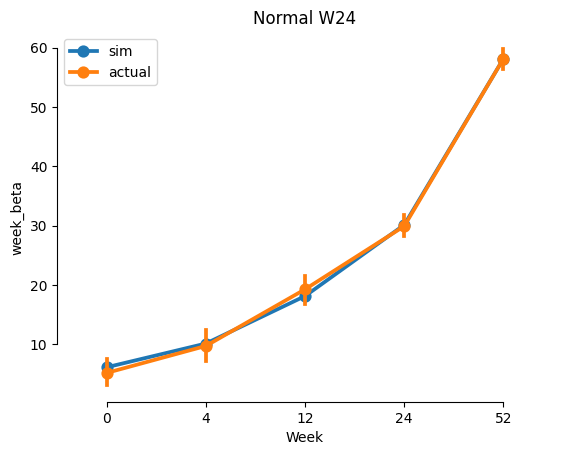

In [15]:
df = sim.y_sim()
y_df = sim.y_kill(df, size = 50)

result= sim.lme_results(y_df)

sns.pointplot(data = result, x = 'Week', y = 'week_beta', label = 'sim')
sns.pointplot(data = y_df, x = 'Week', y = 'y', label = 'actual')

plt.legend()
sns.despine(trim = True)
plt.title("Normal W24")
plt.show()